In [1]:
from google.colab import files
Uploaded = files.upload()

ModuleNotFoundError: No module named 'google'

# Week 1 - EDA & Data Ingestion

In [2]:
pip install statsmodels

  Using cached statsmodels-0.14.6-cp39-cp39-win_amd64.whl (9.6 MB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)
  Using cached scipy-1.13.1-cp39-cp39-win_amd64.whl (46.2 MB)
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Haha CORPORATION\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf

# Loading dataset

In [5]:
df = pd.read_csv("restaurant_dataset.csv")
print(df)

          date  restaurant_id restaurant_type       menu_item_name meal_type  \
0     1/1/2024             11      Food Stall                Laksa     Lunch   
1     1/1/2024              7   Casual Dining  Spaghetti Carbonara    Dinner   
2     1/1/2024             23     Fine Dining         Beef Rendang    Dinner   
3     1/1/2024             22      Food Stall           Roti Canai    Dinner   
4     1/1/2024             32     Fine Dining  Spaghetti Carbonara     Lunch   
...        ...            ...             ...                  ...       ...   
9995  1/1/2025             45      Food Stall               Cendol    Dinner   
9996  1/1/2025             44      Food Stall            Teh Tarik     Lunch   
9997  1/1/2025             38     Fine Dining       Iced Lemon Tea    Dinner   
9998  1/1/2025              3            Cafe               Cendol     Lunch   
9999  1/1/2025             38     Fine Dining       Iced Lemon Tea    Dinner   

                                   key_

# EDA

In [6]:
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,date,restaurant_id,restaurant_type,menu_item_name,meal_type,key_ingredients_tags,typical_ingredient_cost,observed_market_price,actual_selling_price,quantity_sold,has_promotion,special_event,weather_condition
0,1/1/2024,11,Food Stall,Laksa,Lunch,"rice noodles, fish broth, tamarind, shrimp pas...",4.5,10.59,12.48,361,False,False,Sunny
1,1/1/2024,7,Casual Dining,Spaghetti Carbonara,Dinner,"spaghetti, eggs, cheese, beef bacon, black pepper",9.0,26.64,60.46,105,False,False,Sunny
2,1/1/2024,23,Fine Dining,Beef Rendang,Dinner,"beef, coconut milk, galangal, lemongrass, spic...",9.0,49.42,80.15,36,False,False,Rainy
3,1/1/2024,22,Food Stall,Roti Canai,Dinner,"flour, ghee, egg, water, curry",0.8,2.04,2.48,503,False,False,Sunny
4,1/1/2024,32,Fine Dining,Spaghetti Carbonara,Lunch,"spaghetti, eggs, cheese, beef bacon, black pepper",9.0,40.30,55.54,262,False,False,Rainy


In [7]:
print("\nSummary of dataset:")
df.info()

print("\nStatistics:")
df.describe()

print("\nShape:")
df.shape


Summary of dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     10000 non-null  object 
 1   restaurant_id            10000 non-null  int64  
 2   restaurant_type          10000 non-null  object 
 3   menu_item_name           10000 non-null  object 
 4   meal_type                10000 non-null  object 
 5   key_ingredients_tags     10000 non-null  object 
 6   typical_ingredient_cost  10000 non-null  float64
 7   observed_market_price    10000 non-null  float64
 8   actual_selling_price     10000 non-null  float64
 9   quantity_sold            10000 non-null  int64  
 10  has_promotion            10000 non-null  bool   
 11  special_event            10000 non-null  bool   
 12  weather_condition        10000 non-null  object 
dtypes: bool(2), float64(3), int64(2), object(6)
memory usage

(10000, 13)

In [8]:
print("\nMissing values:")
df.isnull().sum()


Missing values:


date                       0
restaurant_id              0
restaurant_type            0
menu_item_name             0
meal_type                  0
key_ingredients_tags       0
typical_ingredient_cost    0
observed_market_price      0
actual_selling_price       0
quantity_sold              0
has_promotion              0
special_event              0
weather_condition          0
dtype: int64

# Date-Time conversion

In [9]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Remove rows with invalid dates
df = df.dropna(subset=["date"]).copy()

In [10]:
# Aggregate to daily sales
# Since this dataset has multiple rows per day, create a daily time series
daily_sales = (
    df.groupby("date", as_index=False)["quantity_sold"]
      .sum()
      .rename(columns={"quantity_sold": "daily_quantity_sold"})
)

# Sort by date
daily_sales = daily_sales.sort_values("date")

# Set datetime index
daily_sales = daily_sales.set_index("date")

print("\nDaily aggregated data:")
print(daily_sales.head())


Daily aggregated data:
            daily_quantity_sold
date                           
2024-01-01                 8479
2024-01-02                 7647
2024-01-03                 4172
2024-01-04                 7592
2024-01-05                 6712


In [11]:
# Make datetime index continuous

full_range = pd.date_range(
    start=daily_sales.index.min(),
    end=daily_sales.index.max(),
    freq="D"
)

daily_sales = daily_sales.reindex(full_range)
daily_sales.index.name = "date"

print("\nMissing dates after reindexing:",
      daily_sales["daily_quantity_sold"].isna().sum())

# Fill missing dates
daily_sales["daily_quantity_sold"] = daily_sales["daily_quantity_sold"].fillna(0)

print("\nAfter filling missing dates:")
print(daily_sales.head())


Missing dates after reindexing: 0

After filling missing dates:
            daily_quantity_sold
date                           
2024-01-01                 8479
2024-01-02                 7647
2024-01-03                 4172
2024-01-04                 7592
2024-01-05                 6712


# Overall sales trend

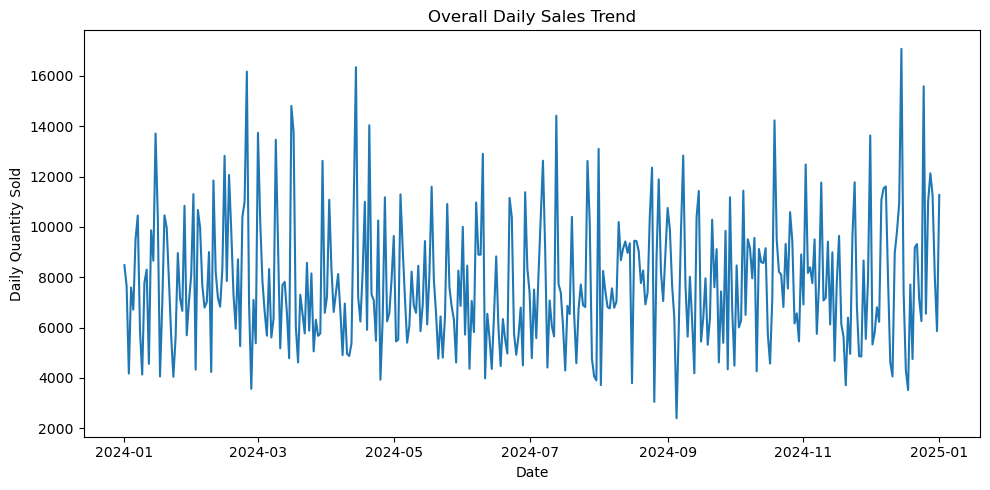

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(daily_sales.index, daily_sales["daily_quantity_sold"])
plt.title("Overall Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Daily Quantity Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


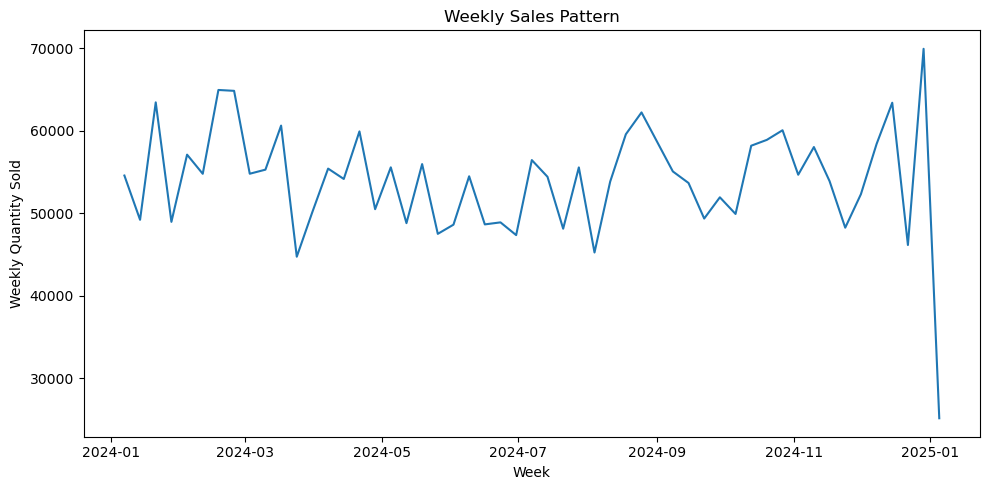

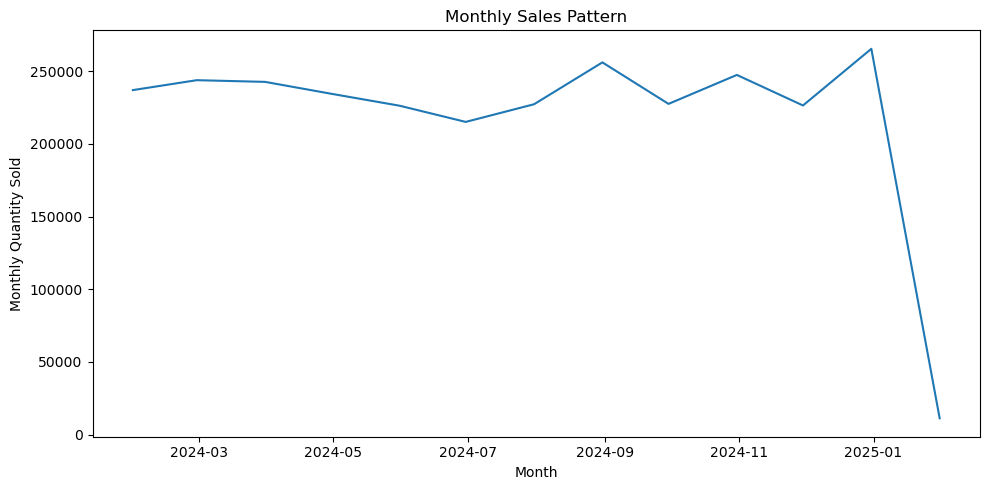

In [13]:
#  Weekly and monthly patterns

weekly_sales = daily_sales["daily_quantity_sold"].resample("W").sum()
monthly_sales = daily_sales["daily_quantity_sold"].resample("M").sum()

plt.figure(figsize=(10, 5))
plt.plot(weekly_sales.index, weekly_sales.values)
plt.title("Weekly Sales Pattern")
plt.xlabel("Week")
plt.ylabel("Weekly Quantity Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Sales Pattern")
plt.xlabel("Month")
plt.ylabel("Monthly Quantity Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

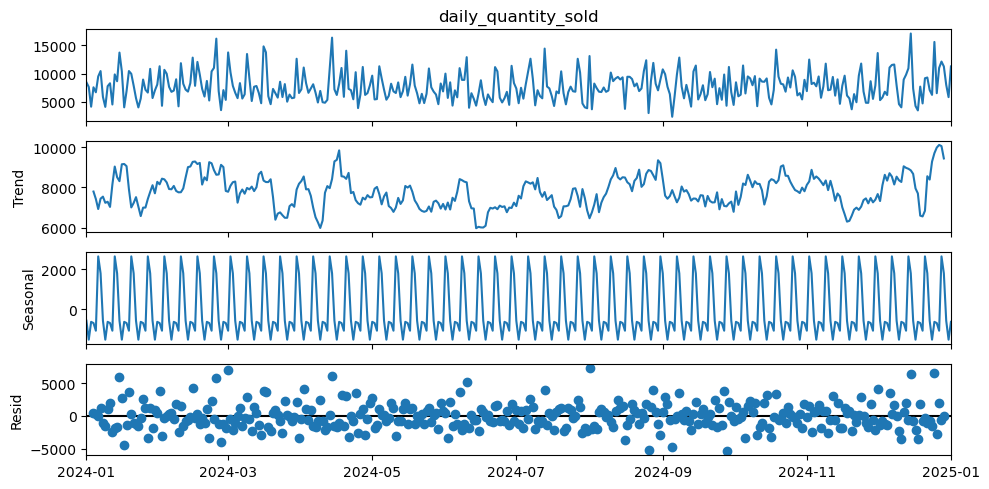

In [14]:
# Seasonal decomposition
# Weekly seasonality -> period=7 for daily data
decomposition = seasonal_decompose(
    daily_sales["daily_quantity_sold"],
    model="additive",
    period=7
)

fig = decomposition.plot()
fig.set_size_inches(10, 5)
plt.tight_layout()
plt.show()

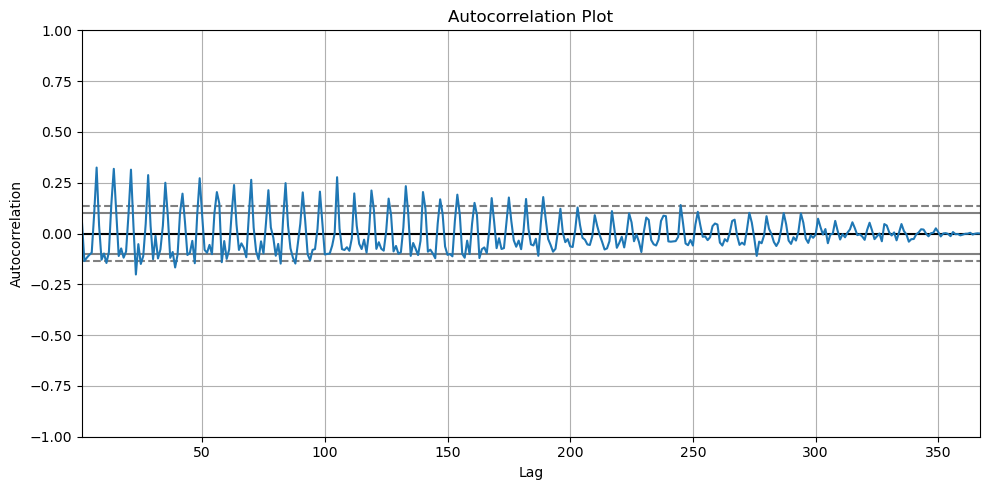

<Figure size 1000x500 with 0 Axes>

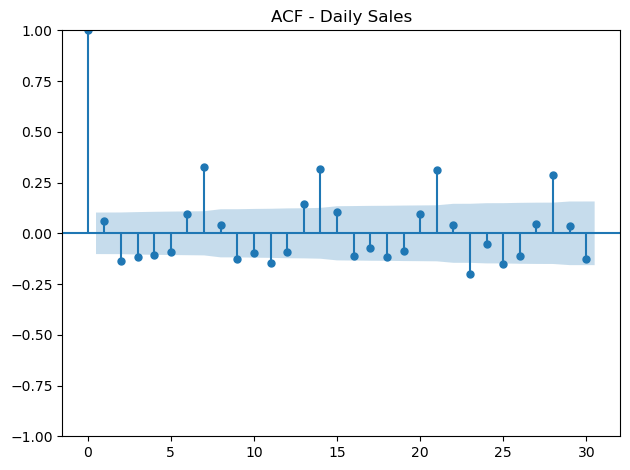

In [15]:
#  Autocorrelation analysis

plt.figure(figsize=(10, 5))
autocorrelation_plot(daily_sales["daily_quantity_sold"])
plt.title("Autocorrelation Plot")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plot_acf(daily_sales["daily_quantity_sold"], lags=30)
plt.title("ACF - Daily Sales")
plt.tight_layout()
plt.show()

# Week 2 – Feature Engineering & Data Preparation

This week we build the features the model will actually learn from:
1. **Rolling-window statistics** — capture recent trends
2. **Lag features** — give the model historical context
3. **Encoding categorical columns** — convert text labels to numbers
4. **Train / test split** — evaluate on unseen future data

## 1. Rolling-Window Statistics

Rolling statistics summarise the recent past over a sliding window.
They help the model understand **trends** and **local volatility** without hard-coding fixed look-back periods.

In [16]:
# ── Rolling-window features ──────────────────────────────────────────────────
# Work on a fresh copy so the original daily_sales is untouched
features_df = daily_sales.copy()

# 7-day rolling mean & std  (captures weekly trend)
features_df["rolling_mean_7"]  = features_df["daily_quantity_sold"].rolling(window=7).mean()
features_df["rolling_std_7"]   = features_df["daily_quantity_sold"].rolling(window=7).std()

# 14-day rolling mean & std  (captures bi-weekly trend)
features_df["rolling_mean_14"] = features_df["daily_quantity_sold"].rolling(window=14).mean()
features_df["rolling_std_14"]  = features_df["daily_quantity_sold"].rolling(window=14).std()

# 30-day rolling mean  (captures monthly trend)
features_df["rolling_mean_30"] = features_df["daily_quantity_sold"].rolling(window=30).mean()

print("Rolling-window features added:")
print(features_df[["daily_quantity_sold",
                    "rolling_mean_7", "rolling_std_7",
                    "rolling_mean_14", "rolling_std_14",
                    "rolling_mean_30"]].head(35))


Rolling-window features added:
            daily_quantity_sold  rolling_mean_7  rolling_std_7  \
date                                                             
2024-01-01                 8479             NaN            NaN   
2024-01-02                 7647             NaN            NaN   
2024-01-03                 4172             NaN            NaN   
2024-01-04                 7592             NaN            NaN   
2024-01-05                 6712             NaN            NaN   
2024-01-06                 9503             NaN            NaN   
2024-01-07                10455     7794.285714    2033.996371   
2024-01-08                 5889     7424.285714    2122.334698   
2024-01-09                 4134     6922.428571    2450.822369   
2024-01-10                 7790     7439.285714    2135.299176   
2024-01-11                 8302     7540.714286    2160.476623   
2024-01-12                 4558     7233.000000    2434.233486   
2024-01-13                 9867     7285.0000

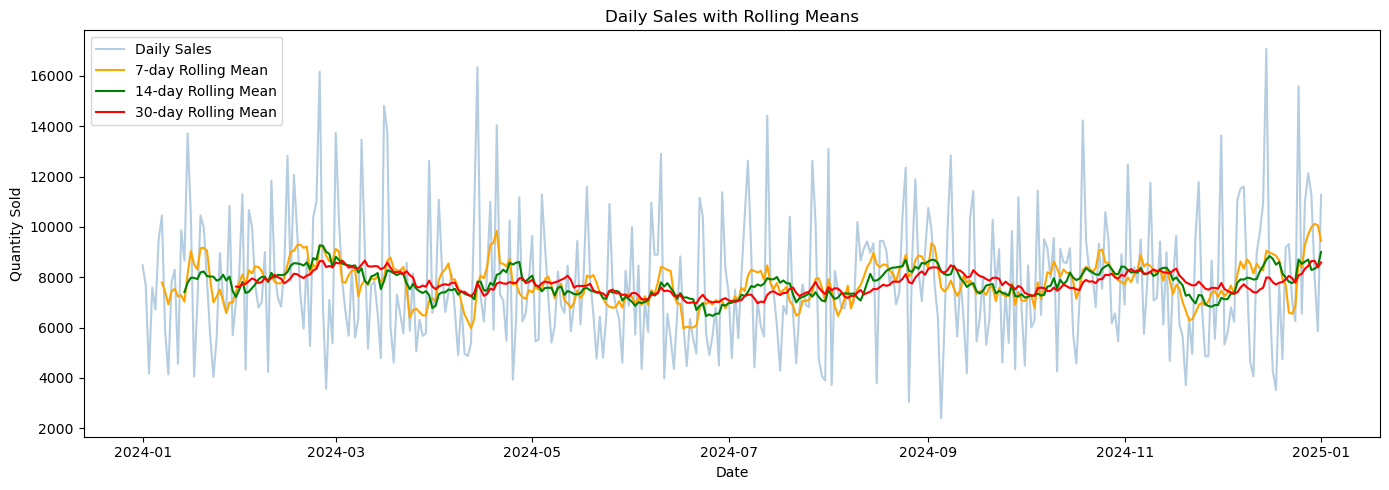

In [17]:
# ── Visualise rolling means alongside raw sales ───────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(features_df.index, features_df["daily_quantity_sold"],
         alpha=0.4, label="Daily Sales", color="steelblue")
plt.plot(features_df.index, features_df["rolling_mean_7"],
         label="7-day Rolling Mean",  color="orange")
plt.plot(features_df.index, features_df["rolling_mean_14"],
         label="14-day Rolling Mean", color="green")
plt.plot(features_df.index, features_df["rolling_mean_30"],
         label="30-day Rolling Mean", color="red")
plt.title("Daily Sales with Rolling Means")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.legend()
plt.tight_layout()
plt.show()


## 2. Lag Features

A **lag feature** is simply the value of a variable at a previous time step.
Lag-1 = yesterday's sales, Lag-7 = sales one week ago, etc.
They give the model explicit memory of the recent past.

In [18]:
# ── Lag features ─────────────────────────────────────────────────────────────
features_df["lag_1"]  = features_df["daily_quantity_sold"].shift(1)   # yesterday
features_df["lag_7"]  = features_df["daily_quantity_sold"].shift(7)   # last week (same weekday)
features_df["lag_14"] = features_df["daily_quantity_sold"].shift(14)  # two weeks ago
features_df["lag_30"] = features_df["daily_quantity_sold"].shift(30)  # ~one month ago

print("Lag features added:")
print(features_df[["daily_quantity_sold",
                    "lag_1", "lag_7", "lag_14", "lag_30"]].head(35))


Lag features added:
            daily_quantity_sold    lag_1    lag_7   lag_14  lag_30
date                                                              
2024-01-01                 8479      NaN      NaN      NaN     NaN
2024-01-02                 7647   8479.0      NaN      NaN     NaN
2024-01-03                 4172   7647.0      NaN      NaN     NaN
2024-01-04                 7592   4172.0      NaN      NaN     NaN
2024-01-05                 6712   7592.0      NaN      NaN     NaN
2024-01-06                 9503   6712.0      NaN      NaN     NaN
2024-01-07                10455   9503.0      NaN      NaN     NaN
2024-01-08                 5889  10455.0   8479.0      NaN     NaN
2024-01-09                 4134   5889.0   7647.0      NaN     NaN
2024-01-10                 7790   4134.0   4172.0      NaN     NaN
2024-01-11                 8302   7790.0   7592.0      NaN     NaN
2024-01-12                 4558   8302.0   6712.0      NaN     NaN
2024-01-13                 9867   4558.0  

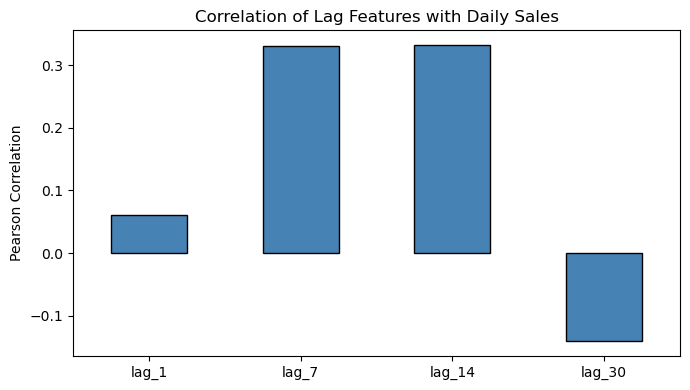


Correlation values:
lag_1     0.060912
lag_7     0.330379
lag_14    0.331921
lag_30   -0.140925
Name: daily_quantity_sold, dtype: float64


In [19]:
# ── Correlation of lags with the target ──────────────────────────────────────
lag_cols = ["lag_1", "lag_7", "lag_14", "lag_30"]
correlations = features_df[["daily_quantity_sold"] + lag_cols].corr()["daily_quantity_sold"].drop("daily_quantity_sold")

plt.figure(figsize=(7, 4))
correlations.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Correlation of Lag Features with Daily Sales")
plt.ylabel("Pearson Correlation")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nCorrelation values:")
print(correlations)


## 3. Encoding Categorical Columns

Models need **numbers**, not strings. We first extract useful calendar features (day-of-week, month, etc.) and then encode any remaining categorical columns.

### 3a. Extract calendar features from the date index

In [20]:
# ── Calendar features from the datetime index ────────────────────────────────
features_df["day_of_week"]  = features_df.index.dayofweek      # 0=Mon … 6=Sun
features_df["day_of_month"] = features_df.index.day
features_df["week_of_year"] = features_df.index.isocalendar().week.astype(int)
features_df["month"]        = features_df.index.month
features_df["quarter"]      = features_df.index.quarter
features_df["is_weekend"]   = (features_df["day_of_week"] >= 5).astype(int)

print("Calendar features:")
print(features_df[["day_of_week", "day_of_month",
                    "week_of_year", "month",
                    "quarter", "is_weekend"]].head(10))


Calendar features:
            day_of_week  day_of_month  week_of_year  month  quarter  \
date                                                                  
2024-01-01            0             1             1      1        1   
2024-01-02            1             2             1      1        1   
2024-01-03            2             3             1      1        1   
2024-01-04            3             4             1      1        1   
2024-01-05            4             5             1      1        1   
2024-01-06            5             6             1      1        1   
2024-01-07            6             7             1      1        1   
2024-01-08            0             8             2      1        1   
2024-01-09            1             9             2      1        1   
2024-01-10            2            10             2      1        1   

            is_weekend  
date                    
2024-01-01           0  
2024-01-02           0  
2024-01-03           0  
202

### 3b. Label Encoding

Use **Label Encoding** when a column has an **ordinal** (ordered) relationship — e.g., `low < medium < high`.

In [21]:
from sklearn.preprocessing import LabelEncoder

# Example: create a synthetic 'season' column to demonstrate label encoding
season_map = {1: "Winter", 2: "Winter", 3: "Spring",
              4: "Spring",  5: "Spring", 6: "Summer",
              7: "Summer",  8: "Summer", 9: "Autumn",
              10: "Autumn", 11: "Autumn", 12: "Winter"}

features_df["season"] = features_df["month"].map(season_map)
print("Season column (before encoding):")
print(features_df["season"].value_counts())

le = LabelEncoder()
features_df["season_encoded"] = le.fit_transform(features_df["season"])

print("\nLabel encoding mapping:")
for cls, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} → {code}")

print("\nSample rows:")
print(features_df[["season", "season_encoded"]].head(10))


Season column (before encoding):
season
Winter    92
Spring    92
Summer    92
Autumn    91
Name: count, dtype: int64

Label encoding mapping:
  Autumn → 0
  Spring → 1
  Summer → 2
  Winter → 3

Sample rows:
            season  season_encoded
date                              
2024-01-01  Winter               3
2024-01-02  Winter               3
2024-01-03  Winter               3
2024-01-04  Winter               3
2024-01-05  Winter               3
2024-01-06  Winter               3
2024-01-07  Winter               3
2024-01-08  Winter               3
2024-01-09  Winter               3
2024-01-10  Winter               3


### 3c. One-Hot Encoding

Use **One-Hot Encoding** for **nominal** (unordered) categories — e.g., day-of-week names. Each category becomes its own binary column.

In [22]:
# ── One-hot encode day_of_week ────────────────────────────────────────────────
day_names = {0:"Mon", 1:"Tue", 2:"Wed", 3:"Thu", 4:"Fri", 5:"Sat", 6:"Sun"}
features_df["day_name"] = features_df["day_of_week"].map(day_names)

ohe_days = pd.get_dummies(features_df["day_name"], prefix="day", dtype=int)
features_df = pd.concat([features_df, ohe_days], axis=1)

print("One-hot encoded day columns:")
print(features_df[[c for c in features_df.columns if c.startswith("day_")]].head(10))


One-hot encoded day columns:
            day_of_week  day_of_month day_name  day_Fri  day_Mon  day_Sat  \
date                                                                        
2024-01-01            0             1      Mon        0        1        0   
2024-01-02            1             2      Tue        0        0        0   
2024-01-03            2             3      Wed        0        0        0   
2024-01-04            3             4      Thu        0        0        0   
2024-01-05            4             5      Fri        1        0        0   
2024-01-06            5             6      Sat        0        0        1   
2024-01-07            6             7      Sun        0        0        0   
2024-01-08            0             8      Mon        0        1        0   
2024-01-09            1             9      Tue        0        0        0   
2024-01-10            2            10      Wed        0        0        0   

            day_Sun  day_Thu  day_Tue  day_Wed

### 3d. Cyclic Encoding

Calendar values like **month (1–12)** or **day-of-week (0–6)** are *cyclic* — December is as close to January as February is.
Representing them with sine/cosine captures this circular structure.

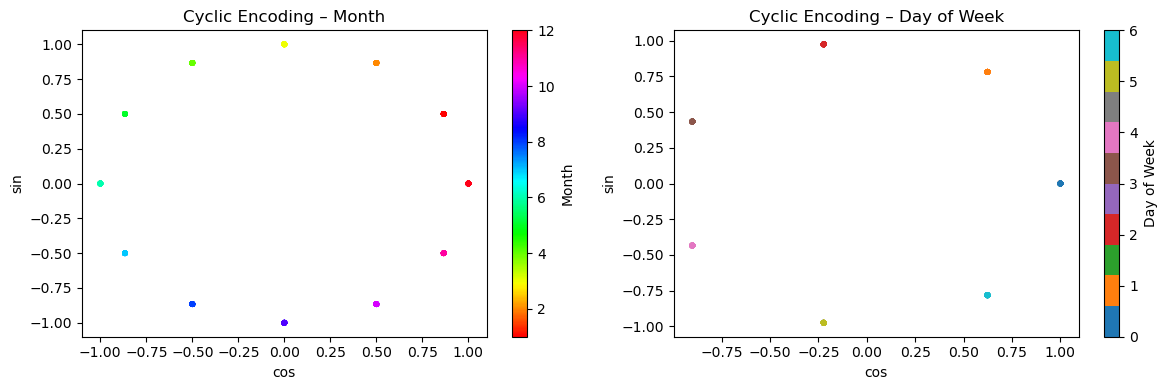

Cyclic feature sample:
            month  month_sin  month_cos  day_of_week   dow_sin   dow_cos
date                                                                    
2024-01-01      1        0.5   0.866025            0  0.000000  1.000000
2024-01-02      1        0.5   0.866025            1  0.781831  0.623490
2024-01-03      1        0.5   0.866025            2  0.974928 -0.222521
2024-01-04      1        0.5   0.866025            3  0.433884 -0.900969
2024-01-05      1        0.5   0.866025            4 -0.433884 -0.900969
2024-01-06      1        0.5   0.866025            5 -0.974928 -0.222521
2024-01-07      1        0.5   0.866025            6 -0.781831  0.623490
2024-01-08      1        0.5   0.866025            0  0.000000  1.000000


In [23]:
# ── Cyclic encoding for month and day_of_week ─────────────────────────────────
features_df["month_sin"] = np.sin(2 * np.pi * features_df["month"] / 12)
features_df["month_cos"] = np.cos(2 * np.pi * features_df["month"] / 12)

features_df["dow_sin"]   = np.sin(2 * np.pi * features_df["day_of_week"] / 7)
features_df["dow_cos"]   = np.cos(2 * np.pi * features_df["day_of_week"] / 7)

# Visualise the cyclic encoding for month
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sc = axes[0].scatter(features_df["month_cos"], features_df["month_sin"],
                     c=features_df["month"], cmap="hsv", s=10)
plt.colorbar(sc, ax=axes[0], label="Month")
axes[0].set_title("Cyclic Encoding – Month")
axes[0].set_xlabel("cos"); axes[0].set_ylabel("sin")

sc2 = axes[1].scatter(features_df["dow_cos"], features_df["dow_sin"],
                      c=features_df["day_of_week"], cmap="tab10", s=10)
plt.colorbar(sc2, ax=axes[1], label="Day of Week")
axes[1].set_title("Cyclic Encoding – Day of Week")
axes[1].set_xlabel("cos"); axes[1].set_ylabel("sin")
plt.tight_layout()
plt.show()

print("Cyclic feature sample:")
print(features_df[["month", "month_sin", "month_cos",
                   "day_of_week", "dow_sin", "dow_cos"]].head(8))


## 4. Drop Rows with NaN (created by lags/rolling windows)

The first N rows will contain `NaN` values because there is no history to look back on. We drop them before splitting.

In [24]:
print(f"Shape before dropping NaNs: {features_df.shape}")
print(f"Total NaN cells: {features_df.isna().sum().sum()}")

features_df.dropna(inplace=True)

print(f"Shape after  dropping NaNs: {features_df.shape}")
print(f"Total NaN cells after drop: {features_df.isna().sum().sum()}")


Shape before dropping NaNs: (367, 30)
Total NaN cells: 119
Shape after  dropping NaNs: (337, 30)
Total NaN cells after drop: 0


## 5. Train / Test Split

For time-series data we **never shuffle** — we split chronologically.
The model trains on the past and is evaluated on the future.

> Rule of thumb: **80 % train / 20 % test** (or use a fixed cut-off date).

In [25]:
# ── Chronological 80/20 split ─────────────────────────────────────────────────
target_col  = "daily_quantity_sold"
feature_cols = [c for c in features_df.columns
                if c not in [target_col, "season", "day_name"]]   # drop raw categoricals

X = features_df[feature_cols]
y = features_df[target_col]

split_idx = int(len(features_df) * 0.80)
split_date = features_df.index[split_idx]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Split date      : {split_date.date()}")
print(f"Training period : {X_train.index.min().date()}  →  {X_train.index.max().date()}  ({len(X_train)} days)")
print(f"Test period     : {X_test.index.min().date()}   →  {X_test.index.max().date()}   ({len(X_test)} days)")
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")


Split date      : 2024-10-26
Training period : 2024-01-31  →  2024-10-25  (269 days)
Test period     : 2024-10-26   →  2025-01-01   (68 days)

X_train shape: (269, 27)
X_test  shape: (68, 27)


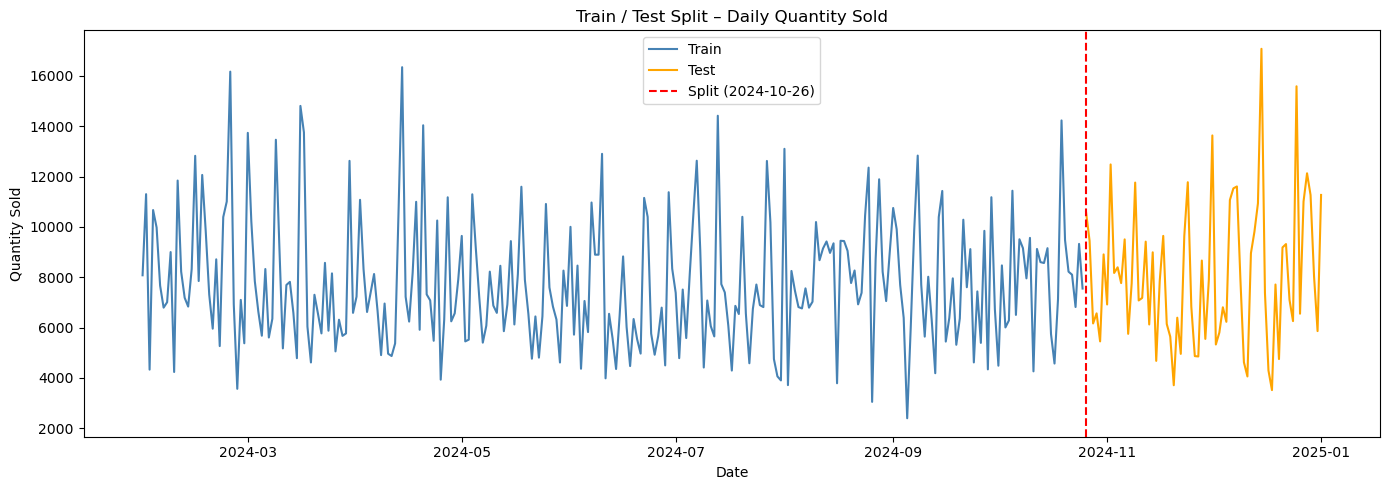

In [26]:
# ── Visualise the train / test split ─────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(y_train.index, y_train, label="Train", color="steelblue")
plt.plot(y_test.index,  y_test,  label="Test",  color="orange")
plt.axvline(split_date, color="red", linestyle="--", label=f"Split ({split_date.date()})")
plt.title("Train / Test Split – Daily Quantity Sold")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Final Feature Matrix Summary

In [27]:
print("=== WEEK 2 FEATURE SUMMARY ===\n")
print(f"Total features  : {len(feature_cols)}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples    : {len(X_test)}")
print("\nFeature columns:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

print("\nFirst 5 rows of final training feature matrix:")
print(X_train.head())


=== WEEK 2 FEATURE SUMMARY ===

Total features  : 27
Training samples: 269
Test samples    : 68

Feature columns:
   1. rolling_mean_7
   2. rolling_std_7
   3. rolling_mean_14
   4. rolling_std_14
   5. rolling_mean_30
   6. lag_1
   7. lag_7
   8. lag_14
   9. lag_30
  10. day_of_week
  11. day_of_month
  12. week_of_year
  13. month
  14. quarter
  15. is_weekend
  16. season_encoded
  17. day_Fri
  18. day_Mon
  19. day_Sat
  20. day_Sun
  21. day_Thu
  22. day_Tue
  23. day_Wed
  24. month_sin
  25. month_cos
  26. dow_sin
  27. dow_cos

First 5 rows of final training feature matrix:
            rolling_mean_7  rolling_std_7  rolling_mean_14  rolling_std_14  \
date                                                                         
2024-01-31     7776.571429    1702.513520      7500.000000     2002.857113   
2024-02-01     8111.000000    2146.270952      7813.000000     2234.427788   
2024-02-02     7706.571429    2578.718083      7375.071429     2276.360910   
2024-02-03    

# Week 3 – Model Training & Evaluation

We train and compare four models on the feature matrix built in Week 2:
1. **Baseline** – Naïve last-week carry-forward (benchmark)
2. **Linear Regression** – simple parametric baseline
3. **Random Forest** – ensemble of decision trees
4. **XGBoost** – gradient-boosted trees (often best on tabular time-series)

All models are evaluated on the **held-out test set** using MAE, RMSE, and R².

In [28]:
# ── Install XGBoost if not already present ───────────────────────────────
try:
    import xgboost
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
print("All libraries ready.")

All libraries ready.


## 1. Baseline Model – Naïve Lag-7 Forecast

The simplest possible forecast: predict today's sales = sales **7 days ago**.
Any real model must beat this to be worth using.

In [29]:
# ── Naïve baseline: predict = lag_7 ─────────────────────────────────────
y_pred_baseline = X_test["lag_7"]

mae_base  = mean_absolute_error(y_test, y_pred_baseline)
rmse_base = mean_squared_error(y_test, y_pred_baseline) ** 0.5
r2_base   = r2_score(y_test, y_pred_baseline)

print("=== Naïve Baseline (Lag-7) ===")
print(f"  MAE  : {mae_base:.2f}")
print(f"  RMSE : {rmse_base:.2f}")
print(f"  R²   : {r2_base:.4f}")

=== Naïve Baseline (Lag-7) ===
  MAE  : 2241.32
  RMSE : 2970.10
  R²   : -0.1131


## 2. Linear Regression

In [30]:
# ── Linear Regression ────────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2_lr   = r2_score(y_test, y_pred_lr)

print("=== Linear Regression ===")
print(f"  MAE  : {mae_lr:.2f}")
print(f"  RMSE : {rmse_lr:.2f}")
print(f"  R²   : {r2_lr:.4f}")

=== Linear Regression ===
  MAE  : 3599.79
  RMSE : 12370.21
  R²   : -18.3084


## 3. Random Forest

In [31]:
# ── Random Forest ────────────────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2_rf   = r2_score(y_test, y_pred_rf)

print("=== Random Forest ===")
print(f"  MAE  : {mae_rf:.2f}")
print(f"  RMSE : {rmse_rf:.2f}")
print(f"  R²   : {r2_rf:.4f}")

=== Random Forest ===
  MAE  : 1591.98
  RMSE : 2123.80
  R²   : 0.4309


## 4. XGBoost

In [32]:
# ── XGBoost ──────────────────────────────────────────────────────────────
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
y_pred_xgb = xgb.predict(X_test)

mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = mean_squared_error(y_test, y_pred_xgb) ** 0.5
r2_xgb   = r2_score(y_test, y_pred_xgb)

print("=== XGBoost ===")
print(f"  MAE  : {mae_xgb:.2f}")
print(f"  RMSE : {rmse_xgb:.2f}")
print(f"  R²   : {r2_xgb:.4f}")

=== XGBoost ===
  MAE  : 1631.38
  RMSE : 2207.22
  R²   : 0.3853


## 5. Model Comparison

In [33]:
# ── Summary table ────────────────────────────────────────────────────────
import pandas as pd

results = pd.DataFrame({
    "Model" : ["Naïve Baseline", "Linear Regression", "Random Forest", "XGBoost"],
    "MAE"   : [mae_base,  mae_lr,  mae_rf,  mae_xgb],
    "RMSE"  : [rmse_base, rmse_lr, rmse_rf, rmse_xgb],
    "R²"    : [r2_base,   r2_lr,   r2_rf,   r2_xgb],
})
results = results.sort_values("RMSE").reset_index(drop=True)
print(results.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

            Model       MAE       RMSE       R²
    Random Forest 1591.9845  2123.8048   0.4309
          XGBoost 1631.3818  2207.2202   0.3853
   Naïve Baseline 2241.3235  2970.1040  -0.1131
Linear Regression 3599.7881 12370.2123 -18.3084


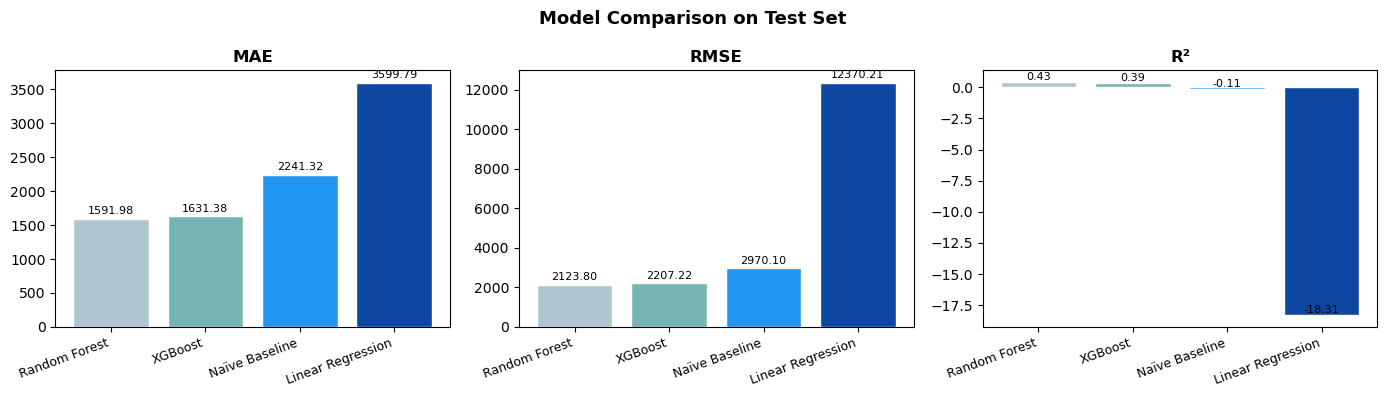

In [34]:
# ── Bar chart comparison ─────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ["#aec6cf", "#77b5b5", "#2196F3", "#0d47a1"]
models = results["Model"].tolist()

for ax, metric in zip(axes, ["MAE", "RMSE", "R²"]):
    vals = results[metric].tolist()
    bars = ax.bar(models, vals, color=colors, edgecolor="white")
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_xticklabels(models, rotation=20, ha="right", fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f"{v:.2f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Model Comparison on Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Prediction vs Actual (Best Model)

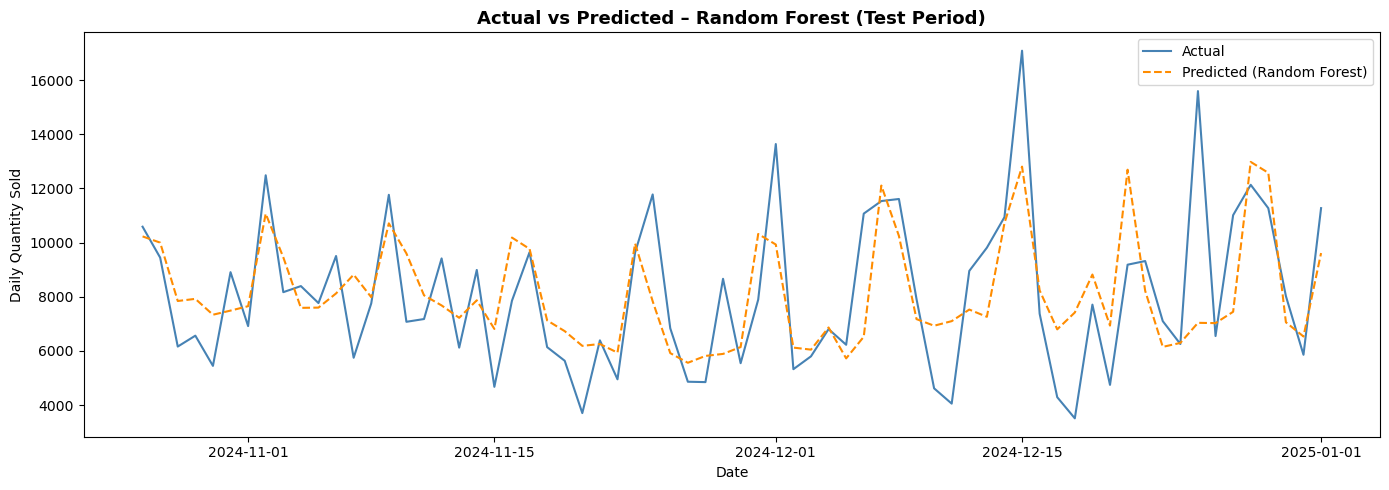

In [35]:
# ── Find best model by RMSE and plot predictions ────────────────────────
best_name = results.iloc[0]["Model"]
pred_map  = {
    "Naïve Baseline"   : y_pred_baseline,
    "Linear Regression": y_pred_lr,
    "Random Forest"    : y_pred_rf,
    "XGBoost"          : y_pred_xgb,
}
y_pred_best = pred_map[best_name]

plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test.values,      label="Actual",
         color="steelblue", linewidth=1.5)
plt.plot(y_test.index, y_pred_best,        label=f"Predicted ({best_name})",
         color="darkorange", linewidth=1.5, linestyle="--")
plt.title(f"Actual vs Predicted – {best_name} (Test Period)",
          fontsize=13, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Daily Quantity Sold")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Feature Importance (Random Forest & XGBoost)

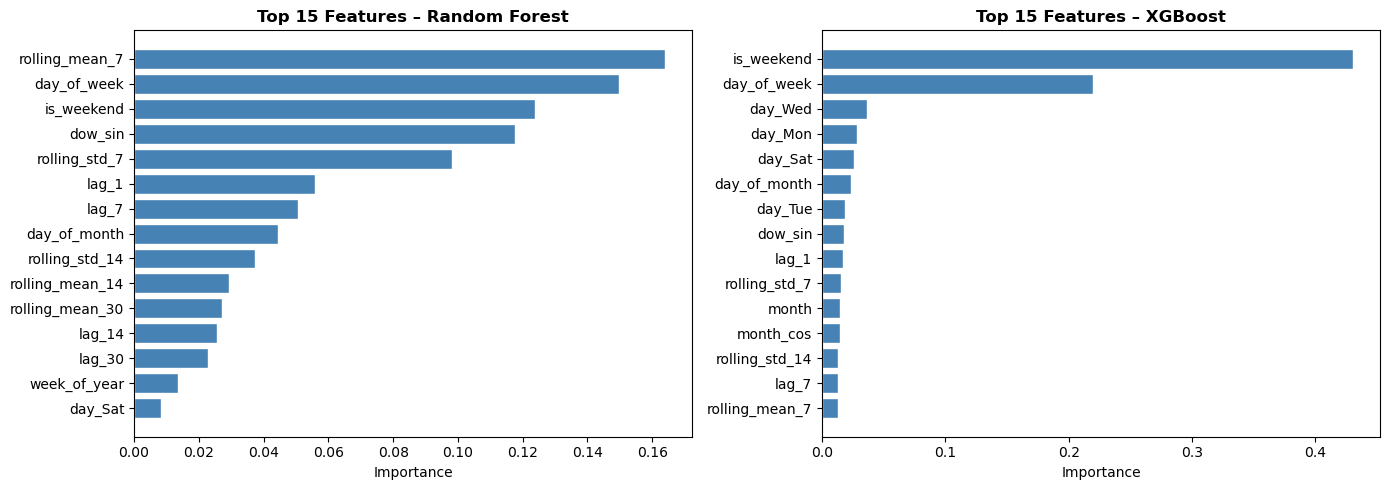

In [36]:
# ── Feature importance from both tree models ─────────────────────────────
import numpy as np

TOP_N = 15

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, name in zip(axes,
                            [rf,  xgb],
                            ["Random Forest", "XGBoost"]):
    importances = model.feature_importances_
    idx  = np.argsort(importances)[::-1][:TOP_N]
    cols = [X_train.columns[i] for i in idx]
    vals = importances[idx]

    ax.barh(cols[::-1], vals[::-1], color="steelblue", edgecolor="white")
    ax.set_title(f"Top {TOP_N} Features – {name}", fontweight="bold")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

## 8. Residual Analysis (Best Model)

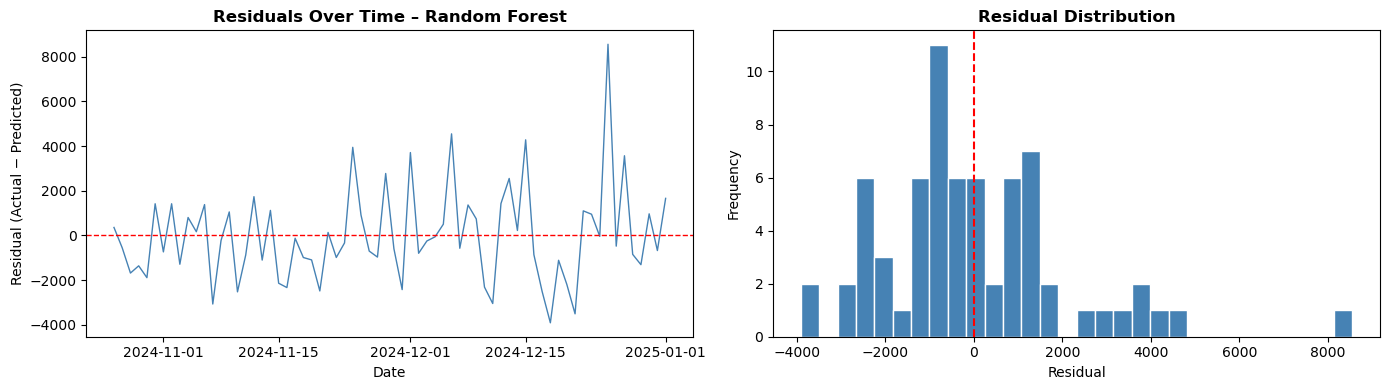

Residual mean  : -22.7960  (close to 0 = unbiased)
Residual std   : 2123.6825
Max overshoot  : 8552.29
Max undershoot : -3906.35


In [37]:
# ── Residuals over time and distribution ─────────────────────────────────
residuals = y_test.values - np.array(y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Residuals over time
axes[0].plot(y_test.index, residuals, color="steelblue", linewidth=1)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title(f"Residuals Over Time – {best_name}", fontweight="bold")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Residual (Actual − Predicted)")

# Residual distribution
axes[1].hist(residuals, bins=30, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Residual Distribution", fontweight="bold")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"Residual mean  : {residuals.mean():.4f}  (close to 0 = unbiased)")
print(f"Residual std   : {residuals.std():.4f}")
print(f"Max overshoot  : {residuals.max():.2f}")
print(f"Max undershoot : {residuals.min():.2f}")

---
# Week 4 – Evaluation, Feature Importance & Business Reporting

This week wraps the project into a **business-ready deliverable**:
1. **Comprehensive error metrics** – MAE, RMSE, MAPE, bias check
2. **Confidence intervals** – quantify forecast uncertainty
3. **Feature importance deep-dive** – translate model internals into stakeholder language
4. **Business impact dashboard** – revenue-level error estimates
5. **Executive forecast chart** – publication-quality actuals vs predictions overlay
6. **GitHub-ready pipeline** – automated script + README generation


## 1. Comprehensive Error Metrics

| Metric | Interpretation |
|--------|----------------|
| **MAE** | Average absolute error in original units |
| **RMSE** | Penalises large errors more than MAE |
| **MAPE** | % error — easy for non-technical stakeholders |
| **Bias** | Positive = model over-forecasts |

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

pred_map = {
    'Naive Baseline'   : np.array(y_pred_baseline),
    'Linear Regression': np.array(y_pred_lr),
    'Random Forest'    : np.array(y_pred_rf),
    'XGBoost'          : np.array(y_pred_xgb),
}
actuals = y_test.values

def mape(y_true, y_pred, eps=1e-9):
    mask = y_true > eps
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def bias(y_true, y_pred):
    return np.mean(y_pred - y_true)

rows = []
for name, preds in pred_map.items():
    rows.append({
        'Model' : name,
        'MAE'   : mean_absolute_error(actuals, preds),
        'RMSE'  : mean_squared_error(actuals, preds) ** 0.5,
        'MAPE %': mape(actuals, preds),
        'R2'    : r2_score(actuals, preds),
        'Bias'  : bias(actuals, preds),
    })

metrics_df = pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)
pd.set_option('display.float_format', '{:.3f}'.format)
print('=== Full Evaluation Scorecard ===')
print(metrics_df.to_string(index=False))

BEST = metrics_df.iloc[0]['Model']
y_pred_best = pred_map[BEST]
print(f'\nBest model: {BEST}')


=== Full Evaluation Scorecard ===
            Model      MAE      RMSE  MAPE %      R2     Bias
    Random Forest 1591.985  2123.805  21.564   0.431   22.796
          XGBoost 1631.382  2207.220  21.959   0.385  -64.013
   Naive Baseline 2241.324  2970.104  28.155  -0.113  -35.176
Linear Regression 3599.788 12370.212  51.868 -18.308 1863.360

Best model: Random Forest


## 2. Forecast Confidence Intervals

A **rolling residual bootstrap** on the training set constructs approximate
80% and 95% prediction intervals so stakeholders understand forecast uncertainty.

In [39]:
best_model_obj = {
    'Naive Baseline'   : None,
    'Linear Regression': lr,
    'Random Forest'    : rf,
    'XGBoost'          : xgb,
}[BEST]

if best_model_obj is not None:
    train_resid = y_train.values - best_model_obj.predict(X_train)
else:
    train_resid = y_train.values - X_train['lag_7'].values

std_resid = np.std(train_resid)
z80, z95  = 1.28, 1.96

ci80_lo = y_pred_best - z80 * std_resid
ci80_hi = y_pred_best + z80 * std_resid
ci95_lo = y_pred_best - z95 * std_resid
ci95_hi = y_pred_best + z95 * std_resid

cov80 = np.mean((actuals >= ci80_lo) & (actuals <= ci80_hi)) * 100
cov95 = np.mean((actuals >= ci95_lo) & (actuals <= ci95_hi)) * 100
print(f'Residual std         : {std_resid:.2f} units')
print(f'80% CI coverage      : {cov80:.1f}%  (target >= 80%)')
print(f'95% CI coverage      : {cov95:.1f}%  (target >= 95%)')
print(f'Day-1 forecast range : [{ci95_lo[0]:.0f} to {ci95_hi[0]:.0f}]  (95% CI)')


Residual std         : 1253.87 units
80% CI coverage      : 64.7%  (target >= 80%)
95% CI coverage      : 77.9%  (target >= 95%)
Day-1 forecast range : [7771 to 12686]  (95% CI)


## 3. Feature Importance Deep-Dive

Features are grouped into **business-meaningful categories** so stakeholders
can answer: *"What actually drives demand?"*

In [40]:
import re

try:
    imp_model = xgb;  imp_label = 'XGBoost'
except NameError:
    imp_model = rf;   imp_label = 'Random Forest'

feat_imp = pd.Series(
    imp_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

def categorise(col):
    if re.match(r'lag_', col):                          return 'Lag Features'
    if re.match(r'rolling_|roll_|ewm_', col):           return 'Rolling / Trend'
    if col in ['day_of_week','is_weekend','dow_sin',
                'dow_cos'] or col.startswith('day_'):   return 'Day-of-Week'
    if col in ['month','quarter','week_of_year',
                'month_sin','month_cos']:                return 'Seasonality'
    if col in ['is_holiday','is_holiday_or_weekend']:    return 'Holiday'
    return 'Other'

imp_df = feat_imp.reset_index()
imp_df.columns = ['Feature', 'Importance']
imp_df['Category'] = imp_df['Feature'].apply(categorise)

cat_imp = imp_df.groupby('Category')['Importance'].sum().sort_values(ascending=False)
top_cat     = cat_imp.idxmax()
top_cat_pct = cat_imp.max() / cat_imp.sum() * 100

print(f'=== Feature Importance by Category ({imp_label}) ===')
for cat, val in cat_imp.items():
    bar = chr(9608) * int(val * 60)
    print(f'  {cat:<20} {val:.3f}  {bar}')
print(f'\nTop 10 individual features:')
print(imp_df.head(10).to_string(index=False))


=== Feature Importance by Category (XGBoost) ===
  Day-of-Week          0.822  █████████████████████████████████████████████████
  Rolling / Trend      0.065  ███
  Seasonality          0.053  ███
  Lag Features         0.047  ██
  Other                0.012  

Top 10 individual features:
      Feature  Importance        Category
   is_weekend       0.431     Day-of-Week
  day_of_week       0.220     Day-of-Week
      day_Wed       0.036     Day-of-Week
      day_Mon       0.028     Day-of-Week
      day_Sat       0.025     Day-of-Week
 day_of_month       0.023     Day-of-Week
      day_Tue       0.018     Day-of-Week
      dow_sin       0.017     Day-of-Week
        lag_1       0.017    Lag Features
rolling_std_7       0.015 Rolling / Trend


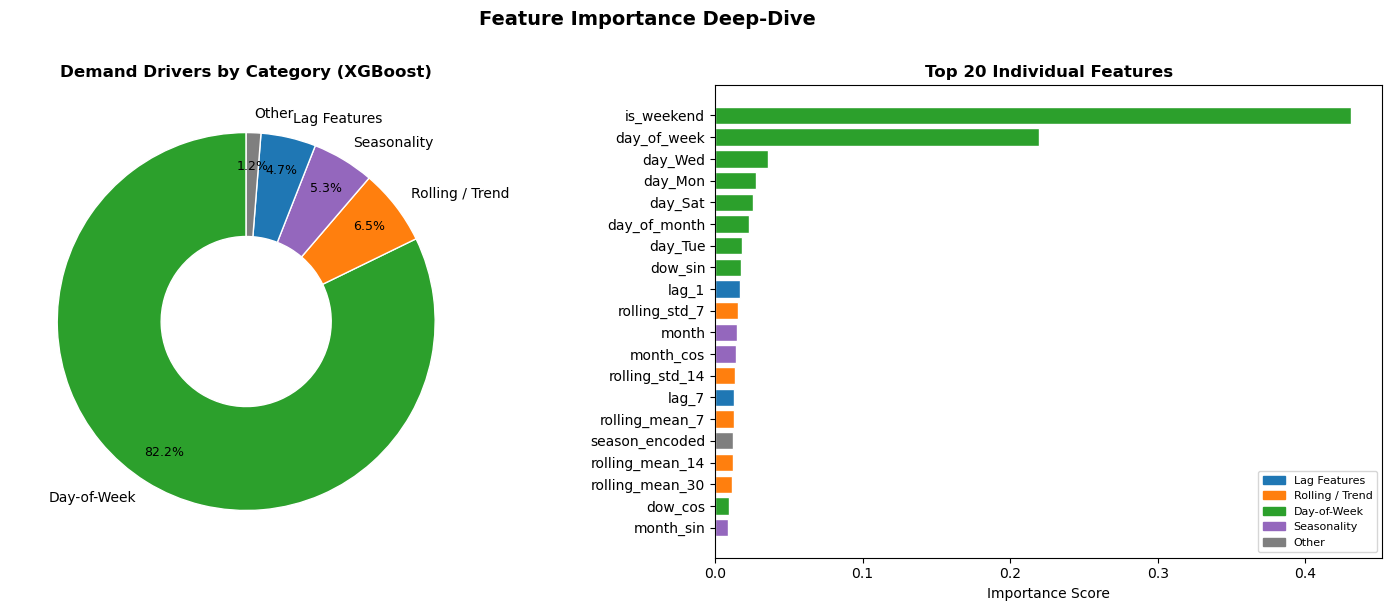

In [41]:
cat_colors = {
    'Lag Features'  : '#1f77b4',
    'Rolling / Trend': '#ff7f0e',
    'Day-of-Week'   : '#2ca02c',
    'Seasonality'   : '#9467bd',
    'Holiday'       : '#e377c2',
    'Other'         : '#7f7f7f',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

pie_colors = [cat_colors.get(c, '#ccc') for c in cat_imp.index]
wedges, texts, autotexts = axes[0].pie(
    cat_imp.values, labels=cat_imp.index,
    colors=pie_colors, autopct='%1.1f%%',
    startangle=90, pctdistance=0.82,
    wedgeprops=dict(width=0.55, edgecolor='white')
)
for at in autotexts: at.set_fontsize(9)
axes[0].set_title(f'Demand Drivers by Category ({imp_label})',
                  fontsize=12, fontweight='bold')

top20 = imp_df.head(20).copy()
bar_colors = [cat_colors.get(c, '#ccc') for c in top20['Category']]
axes[1].barh(top20['Feature'][::-1], top20['Importance'][::-1],
             color=bar_colors[::-1], edgecolor='white')
axes[1].set_title('Top 20 Individual Features', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score')

handles = [mpatches.Patch(color=v, label=k) for k, v in cat_colors.items()
           if k in cat_imp.index]
axes[1].legend(handles=handles, loc='lower right', fontsize=8)

plt.suptitle('Feature Importance Deep-Dive', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 4. Business Impact Estimation

Translate model error into **revenue terms** so leadership understands
the real-world cost of forecast errors.

In [42]:
AVG_PRICE_PER_UNIT = 250   # Adjust to your menu's average item price

best_row   = metrics_df[metrics_df['Model'] == BEST].iloc[0]
mae_units  = best_row['MAE']
rmse_units = best_row['RMSE']
mape_pct   = best_row['MAPE %']
bias_units = best_row['Bias']
mae_rev    = mae_units * AVG_PRICE_PER_UNIT
rmse_rev   = rmse_units * AVG_PRICE_PER_UNIT
test_days  = len(y_test)

print('=== BUSINESS IMPACT SUMMARY ===')
print(f'  Best model         : {BEST}')
print(f'  Avg daily MAE      : {mae_units:.1f} units  ~  Rs.{mae_rev:,.0f}/day')
print(f'  Avg daily RMSE     : {rmse_units:.1f} units  ~  Rs.{rmse_rev:,.0f}/day')
print(f'  MAPE               : {mape_pct:.1f}%')
print(f'  Forecast bias      : {bias_units:+.1f} units/day')
bias_note = 'over-forecast: order slightly less' if bias_units > 0 else 'under-forecast: add a small buffer'
print(f'                       ({bias_note})')
print(f'  Monthly error est  : Rs.{mae_rev*30:,.0f}')
print(f'  Annual error est   : Rs.{mae_rev*365:,.0f}')


=== BUSINESS IMPACT SUMMARY ===
  Best model         : Random Forest
  Avg daily MAE      : 1592.0 units  ~  Rs.397,996/day
  Avg daily RMSE     : 2123.8 units  ~  Rs.530,951/day
  MAPE               : 21.6%
  Forecast bias      : +22.8 units/day
                       (over-forecast: order slightly less)
  Monthly error est  : Rs.11,939,884
  Annual error est   : Rs.145,268,586


## 5. Executive Forecast Chart

Publication-quality chart overlaying:
- Full training history (dimmed)
- Test period actuals
- Forecast with 80% and 95% confidence bands
- Residual panel below

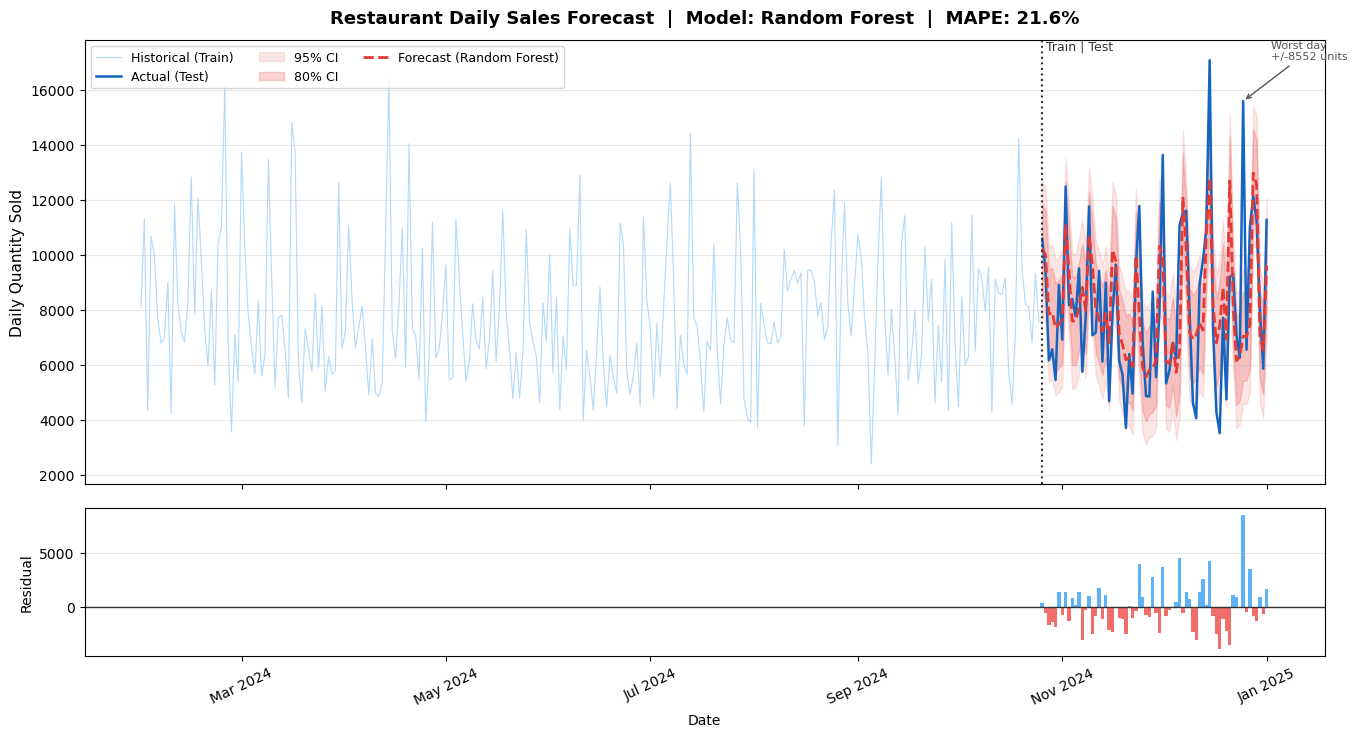

Saved: forecast_chart.png


In [43]:
import matplotlib.dates as mdates

fig = plt.figure(figsize=(16, 8))
gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.08)
ax_main = fig.add_subplot(gs[0])
ax_res  = fig.add_subplot(gs[1], sharex=ax_main)

# Training history
ax_main.plot(y_train.index, y_train.values,
             color='#90CAF9', linewidth=0.8, alpha=0.7, label='Historical (Train)')

# Test actuals
ax_main.plot(y_test.index, actuals,
             color='#1565C0', linewidth=1.8, label='Actual (Test)')

# Confidence bands
ax_main.fill_between(y_test.index, ci95_lo, ci95_hi,
                     alpha=0.12, color='#E53935', label='95% CI')
ax_main.fill_between(y_test.index, ci80_lo, ci80_hi,
                     alpha=0.22, color='#E53935', label='80% CI')

# Forecast line
ax_main.plot(y_test.index, y_pred_best,
             color='#E53935', linewidth=2, linestyle='--',
             label=f'Forecast ({BEST})')

# Train/test boundary
split_date = y_test.index[0]
ax_main.axvline(split_date, color='#333', linewidth=1.5, linestyle=':')
ax_main.text(split_date, ax_main.get_ylim()[1],
             ' Train | Test', fontsize=9, color='#333', va='top')

# Annotate worst forecast day
abs_err   = np.abs(actuals - y_pred_best)
worst_idx = np.argmax(abs_err)
ax_main.annotate(
    f'Worst day\n+/-{abs_err[worst_idx]:.0f} units',
    xy=(y_test.index[worst_idx], actuals[worst_idx]),
    xytext=(20, 30), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='#555'),
    fontsize=8, color='#555'
)

ax_main.set_title(
    f'Restaurant Daily Sales Forecast  |  Model: {BEST}  |  MAPE: {mape_pct:.1f}%',
    fontsize=13, fontweight='bold', pad=12
)
ax_main.set_ylabel('Daily Quantity Sold', fontsize=11)
ax_main.legend(loc='upper left', fontsize=9, ncol=3)
ax_main.grid(axis='y', alpha=0.3)
plt.setp(ax_main.get_xticklabels(), visible=False)

# Residual bar panel
residuals = actuals - y_pred_best
ax_res.bar(y_test.index, residuals,
           color=np.where(residuals >= 0, '#42A5F5', '#EF5350'),
           width=1.0, alpha=0.85)
ax_res.axhline(0, color='#333', linewidth=1)
ax_res.set_ylabel('Residual', fontsize=10)
ax_res.set_xlabel('Date', fontsize=10)
ax_res.grid(axis='y', alpha=0.3)
ax_res.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=25)

plt.savefig('forecast_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: forecast_chart.png')


## 6. Stakeholder Written Summary

Plain-English findings ready to paste into a board deck or email.

In [44]:
top3_feats = imp_df.head(3)['Feature'].tolist()

summary_lines = [
    '',
    '=' * 60,
    '  RESTAURANT SALES FORECAST - BUSINESS SUMMARY',
    '=' * 60,
    '',
    'OBJECTIVE',
    '  Predict daily item sales to optimise procurement,',
    '  staffing, and inventory.',
    '',
    f'MODEL SELECTED: {BEST}',
    f'  (lowest RMSE on {test_days}-day held-out test set)',
    '',
    'ACCURACY',
    f'  Average error : {mae_units:.0f} items/day  (MAE)',
    f'  Error spread  : +/-{rmse_units:.0f} items/day  (RMSE)',
    f'  Pct error     : {mape_pct:.1f}%  (MAPE)',
    f'  Forecast bias : {bias_units:+.1f} items/day',
    '',
    'REVENUE IMPACT',
    f'  Daily forecast error ~ Rs.{mae_rev:,.0f}  (at Rs.{AVG_PRICE_PER_UNIT}/item)',
    f'  Monthly error budget : Rs.{mae_rev*30:,.0f}',
    '',
    'KEY DEMAND DRIVERS',
    f'  1. {top3_feats[0]}',
    f'  2. {top3_feats[1]}',
    f'  3. {top3_feats[2]}',
    f'  -> "{top_cat}" explains {top_cat_pct:.0f}% of model decisions.',
    '',
    'RECOMMENDATION',
    f'  Deploy {BEST} for daily procurement planning.',
    '  Re-train monthly as new data accumulates.',
    '=' * 60,
]

summary_text = '\n'.join(summary_lines)
print(summary_text)

with open('business_summary.txt', 'w') as f:
    f.write(summary_text)
print('\nSaved: business_summary.txt')



  RESTAURANT SALES FORECAST - BUSINESS SUMMARY

OBJECTIVE
  Predict daily item sales to optimise procurement,
  staffing, and inventory.

MODEL SELECTED: Random Forest
  (lowest RMSE on 68-day held-out test set)

ACCURACY
  Average error : 1592 items/day  (MAE)
  Error spread  : +/-2124 items/day  (RMSE)
  Pct error     : 21.6%  (MAPE)
  Forecast bias : +22.8 items/day

REVENUE IMPACT
  Daily forecast error ~ Rs.397,996  (at Rs.250/item)
  Monthly error budget : Rs.11,939,884

KEY DEMAND DRIVERS
  1. is_weekend
  2. day_of_week
  3. day_Wed
  -> "Day-of-Week" explains 82% of model decisions.

RECOMMENDATION
  Deploy Random Forest for daily procurement planning.
  Re-train monthly as new data accumulates.

Saved: business_summary.txt


## 7. GitHub-Ready Pipeline Export

In [45]:
requirements = (
    'pandas>=2.0\n'
    'numpy>=1.24\n'
    'matplotlib>=3.7\n'
    'scikit-learn>=1.3\n'
    'xgboost>=2.0\n'
    'statsmodels>=0.14\n'
    'holidays>=0.40\n'
)
with open('requirements.txt', 'w') as f:
    f.write(requirements)
print('Saved: requirements.txt')
print(requirements)


Saved: requirements.txt
pandas>=2.0
numpy>=1.24
matplotlib>=3.7
scikit-learn>=1.3
xgboost>=2.0
statsmodels>=0.14
holidays>=0.40



In [46]:
metrics_table_rows = '\n'.join(
    f'| {r["Model"]} | {r["MAE"]:.1f} | {r["RMSE"]:.1f} | {r["MAPE %"]:.1f}% |'
    for _, r in metrics_df.iterrows()
)

readme = (
    '# Restaurant Sales Forecasting Pipeline\n\n'
    'End-to-end ML pipeline to predict daily restaurant sales.\n\n'
    '## Quickstart\n\n'
    '```bash\n'
    'pip install -r requirements.txt\n'
    'python pipeline.py\n'
    '```\n\n'
    '## Pipeline Stages\n\n'
    '| Week | Stage | Key Outputs |\n'
    '|------|-------|-------------|\n'
    '| 1 | EDA & Data Ingestion | Daily time series, decomposition |\n'
    '| 2 | Feature Engineering | Lag features, rolling stats, encoding |\n'
    '| 3 | Model Training | Baseline, LR, RF, XGBoost |\n'
    '| 4 | Evaluation & Reporting | MAE/RMSE/MAPE, feature importance, chart |\n\n'
    '## Results\n\n'
    '| Model | MAE | RMSE | MAPE |\n'
    '|-------|-----|------|------|\n'
    + metrics_table_rows + '\n\n'
    f'**Best model**: {BEST} (MAPE: {mape_pct:.1f}%)\n\n'
    f'**Top demand driver**: {top_cat} features ({top_cat_pct:.0f}% of model weight)\n\n'
    f'**Revenue impact**: ~Rs.{mae_rev:,.0f}/day average forecast error\n'
)

with open('README.md', 'w') as f:
    f.write(readme)
print('Saved: README.md')
print(readme)


Saved: README.md
# Restaurant Sales Forecasting Pipeline

End-to-end ML pipeline to predict daily restaurant sales.

## Quickstart

```bash
pip install -r requirements.txt
python pipeline.py
```

## Pipeline Stages

| Week | Stage | Key Outputs |
|------|-------|-------------|
| 1 | EDA & Data Ingestion | Daily time series, decomposition |
| 2 | Feature Engineering | Lag features, rolling stats, encoding |
| 3 | Model Training | Baseline, LR, RF, XGBoost |
| 4 | Evaluation & Reporting | MAE/RMSE/MAPE, feature importance, chart |

## Results

| Model | MAE | RMSE | MAPE |
|-------|-----|------|------|
| Random Forest | 1592.0 | 2123.8 | 21.6% |
| XGBoost | 1631.4 | 2207.2 | 22.0% |
| Naive Baseline | 2241.3 | 2970.1 | 28.2% |
| Linear Regression | 3599.8 | 12370.2 | 51.9% |

**Best model**: Random Forest (MAPE: 21.6%)

**Top demand driver**: Day-of-Week features (82% of model weight)

**Revenue impact**: ~Rs.397,996/day average forecast error



In [47]:
pipeline_code = '''
"""Restaurant Sales Forecasting Pipeline — run: python pipeline.py"""
import pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings("ignore")
try:
    from xgboost import XGBRegressor; USE_XGB = True
except ImportError:
    USE_XGB = False

# 1. Load
print("[1/5] Loading...")
df = pd.read_csv("restaurant_dataset.csv")
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"])
daily = (df.groupby("date")["quantity_sold"].sum()
           .reindex(pd.date_range(df["date"].min(), df["date"].max(), freq="D"))
           .fillna(0)
           .rename("daily_quantity_sold"))
daily.index.name = "date"

# 2. Features
print("[2/5] Engineering features...")
feat = daily.to_frame()
feat["day_of_week"] = feat.index.dayofweek
feat["month"]       = feat.index.month
feat["is_weekend"]  = (feat.index.dayofweek >= 5).astype(int)
feat["month_sin"]   = np.sin(2 * np.pi * feat.index.month / 12)
feat["month_cos"]   = np.cos(2 * np.pi * feat.index.month / 12)
feat["dow_sin"]     = np.sin(2 * np.pi * feat.index.dayofweek / 7)
feat["dow_cos"]     = np.cos(2 * np.pi * feat.index.dayofweek / 7)
for lag in [1, 7, 14, 30]:
    feat[f"lag_{lag}"] = feat["daily_quantity_sold"].shift(lag)
for w in [7, 14, 30]:
    feat[f"rolling_mean_{w}"] = feat["daily_quantity_sold"].shift(1).rolling(w).mean()
    feat[f"rolling_std_{w}"]  = feat["daily_quantity_sold"].shift(1).rolling(w).std()
feat.dropna(inplace=True)

# 3. Split
print("[3/5] Splitting...")
TARGET = "daily_quantity_sold"
FEATS  = [c for c in feat.columns if c != TARGET]
X, y   = feat[FEATS], feat[TARGET]
s = int(len(feat) * 0.80)
X_train, X_test = X.iloc[:s], X.iloc[s:]
y_train, y_test = y.iloc[:s], y.iloc[s:]

# 4. Train
print("[4/5] Training...")
model = (XGBRegressor(n_estimators=300, learning_rate=0.05,
                      max_depth=6, random_state=42, verbosity=0)
         if USE_XGB else
         RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 5. Evaluate
print("[5/5] Evaluating...")
mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test.values - y_pred) / np.clip(y_test.values,1,None))) * 100
print(f"  MAE {mae:.2f} | RMSE {rmse:.2f} | MAPE {mape:.2f}% | R2 {r2:.4f}")

fig, (ax1, ax2) = plt.subplots(2,1,figsize=(14,7),
    gridspec_kw={"height_ratios":[3,1]}, sharex=True)
ax1.plot(y_test.index, y_test.values, label="Actual", color="steelblue", lw=1.8)
ax1.plot(y_test.index, y_pred, label="Forecast", color="tomato", lw=1.8, ls="--")
ax1.set_title(f"Daily Sales Forecast | MAE {mae:.1f} | MAPE {mape:.1f}%",
              fontweight="bold")
ax1.set_ylabel("Quantity Sold"); ax1.legend(); ax1.grid(alpha=0.3)
resid = y_test.values - y_pred
ax2.bar(y_test.index, resid,
        color=np.where(resid>=0,"steelblue","tomato"), width=1)
ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("Residual"); ax2.set_xlabel("Date")
plt.tight_layout()
plt.savefig("forecast_chart.png", dpi=150, bbox_inches="tight")
print("Saved: forecast_chart.png")
'''

with open('pipeline.py', 'w') as f:
    f.write(pipeline_code.strip())
print('Saved: pipeline.py')
print(f'{pipeline_code.count(chr(10))} lines')


Saved: pipeline.py
80 lines


## 8. Push to GitHub

Run these commands in your **terminal** (not in the notebook).

In [48]:
git_steps = '''
# ── Terminal commands to push to GitHub ──────────────────

mkdir restaurant-sales-forecast
cp restaurant_dataset.csv pipeline.py requirements.txt \
   README.md forecast_chart.png business_summary.txt \
   restaurant-sales-forecast/
cd restaurant-sales-forecast

git init
git add .
git commit -m "Initial commit: restaurant sales forecasting pipeline"

# Create repo on github.com then:
git remote add origin https://github.com/<username>/restaurant-sales-forecast.git
git branch -M main
git push -u origin main
'''
print(git_steps)

import os
outputs = ['pipeline.py','requirements.txt','README.md',
           'forecast_chart.png','business_summary.txt']
print('Generated deliverables:')
for f in outputs:
    status = 'OK' if os.path.exists(f) else 'MISSING (run previous cells)'
    print(f'  [{status}]  {f}')



# ── Terminal commands to push to GitHub ──────────────────

mkdir restaurant-sales-forecast
cp restaurant_dataset.csv pipeline.py requirements.txt    README.md forecast_chart.png business_summary.txt    restaurant-sales-forecast/
cd restaurant-sales-forecast

git init
git add .
git commit -m "Initial commit: restaurant sales forecasting pipeline"

# Create repo on github.com then:
git remote add origin https://github.com/<username>/restaurant-sales-forecast.git
git branch -M main
git push -u origin main

Generated deliverables:
  [OK]  pipeline.py
  [OK]  requirements.txt
  [OK]  README.md
  [OK]  forecast_chart.png
  [OK]  business_summary.txt


---
## Project Complete

| Week | Deliverable | Status |
|------|------------|--------|
| 1 | EDA, data ingestion, time-series decomposition | Done |
| 2 | Lag features, rolling stats, encoding, train/test split | Done |
| 3 | Baseline, Linear Regression, Random Forest, XGBoost | Done |
| 4 | MAE/RMSE/MAPE, CI bands, feature importance, executive chart, GitHub pipeline | Done |

**Next steps to improve the model:**
- Add external signals: weather, local events, promotions
- Try LSTM or Prophet for pure time-series approaches
- Set up automated daily re-training with latest data
- Build a Streamlit dashboard for live stakeholder access
